# Laboratory Activity: Multivariate Data Analysis with Python


## Part 1. Questions

1. **Hidden patterns.** Can a few underlying factors summarize how electricity access, clean cooking fuels, renewable energy, energy intensity, emissions, and income vary together?
2. **Simpler summary.** How many combined scores do we need to keep most of the information in these energy and development indicators?
3. **Group differences.** Which energy indicators (not income itself) best separate higher-income countries from lower-income countries?


## Part 2. Techniques and why they fit

| Question | Technique | Why it fits |
| --- | --- | --- |
| 1 | Scatter plot matrix and correlation heatmap | Show every pairwise relationship before looking for hidden factors. |
| 1 | Factor analysis, after Bartlett's test and KMO | Looks for a smaller set of unobserved ideas (for example "modern energy access") behind the measured indicators. |
| 2 | Principal components analysis, scree plot, and biplot | Compresses correlated indicators into uncorrelated scores while keeping as much variation as possible. |
| 3 | Linear discriminant analysis | Finds the combination of energy indicators that best separates the two income groups. |
| 3 | Parallel coordinates, trellis display, and radar glyph | Show the same group contrast as a profile, as a decade-by-decade panel, and as a star-shaped icon. |


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import (
    calculate_bartlett_sphericity,
    calculate_kmo,
)
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "clean_global-data-on-sustainable-energy.csv"
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Everyday names used on every chart.
LABELS = {
    "access_electricity_pct": "Electricity access",
    "access_clean_fuels": "Clean cooking fuels",
    "renewable_energy_share_pct": "Renewable energy",
    "low_carbon_electricity_pct": "Low-carbon electricity",
    "log_energy_use_per_capita": "Energy use per person (log)",
    "energy_intensity_mj_per_gdp": "Energy intensity",
    "log_co2_per_capita": "CO2 per person (log)",
    "log_gdp_per_capita": "Income per person (log)",
    "gdp_growth": "Economic growth",
}

FEATURES = list(LABELS)
LDA_FEATURES = [name for name in FEATURES if name != "log_gdp_per_capita"]
GROUP_COLORS = {"Lower-income countries": "#0072B2", "Higher-income countries": "#D55E00"}

TAKEAWAYS = {}


def show_note(takeaway: str, decision: str, key: str) -> None:
    TAKEAWAYS[key] = {"takeaway": takeaway, "decision": decision}
    display(Markdown(f"**Takeaway.** {takeaway}"))
    display(Markdown(f"**Design decision.** {decision}"))


def save(fig, name: str) -> None:
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")


def spread_labels(points, min_dist=0.9, steps=120):
    # Nudge nearby labels apart, mostly up and down, so long names do not share a line.
    placed = np.array(points, dtype=float)
    for _ in range(steps):
        for i in range(len(placed)):
            for j in range(i + 1, len(placed)):
                delta = placed[i] - placed[j]
                dist = np.hypot(delta[0], delta[1])
                if dist >= min_dist:
                    continue
                if abs(delta[1]) < 1e-6:
                    delta[1] = 0.05 if i > j else -0.05
                direction = np.array([0.2 * np.sign(delta[0] if delta[0] else 1), np.sign(delta[1])])
                direction = direction / np.hypot(direction[0], direction[1])
                shift = 0.5 * (min_dist - dist) * direction
                placed[i] += shift
                placed[j] -= shift
    return placed


In [2]:
raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw file: {raw.shape[0]:,} rows and {raw.shape[1]} columns")

drop_cols = [
    col
    for col in raw.columns
    if col.endswith("-1")
    or col.startswith("Is Duplicate")
    or col.endswith("_scaled")
    or "log_transform" in col
    or col.endswith("_outlier_flag")
    or col.endswith("_flag")
]
panel = raw.drop(columns=drop_cols).drop_duplicates(["entity", "year"]).copy()
panel["population"] = panel["density_p_per_km2"] * panel["land_area_km2"]
panel["co2_tonnes_per_person"] = panel["co2_emissions_kt"] * 1000 / panel["population"].replace(0, np.nan)
panel["log_energy_use_per_capita"] = np.log1p(panel["energy_use_per_capita_kwh"])
panel["log_co2_per_capita"] = np.log1p(panel["co2_tonnes_per_person"])
panel["log_gdp_per_capita"] = np.log1p(panel["gdp_per_capita"])

print(f"Country-year panel: {panel.shape[0]:,} rows, {panel['entity'].nunique()} countries")
print(f"Years: {int(panel['year'].min())} to {int(panel['year'].max())}")
panel[["entity", "year", "access_electricity_pct", "renewable_energy_share_pct", "gdp_per_capita"]].head()


Raw file: 56,530 rows and 62 columns
Country-year panel: 2,868 rows, 148 countries
Years: 2000 to 2019


,entity,year,access_electricity_pct,renewable_energy_share_pct,gdp_per_capita
0,Burkina Faso,2007,12.122773,82.43,535.062280
20,Cambodia,2013,57.573696,64.97,1013.420536
40,Central African Republic,2018,14.842376,91.42,475.953814
60,France,2007,100.000000,9.46,41508.432690
80,South Sudan,2013,3.607868,30.13,1779.470365


In [3]:
latest = (
    panel.sort_values(["entity", "year"])
    .groupby("entity", as_index=False)
    .tail(1)
    .reset_index(drop=True)
)
work = latest.replace([np.inf, -np.inf], np.nan).dropna(subset=FEATURES).copy()
print(f"Latest year per country used for the tests and models: {len(work)} countries")
work[FEATURES].rename(columns=LABELS).describe().round(2)


Latest year per country used for the tests and models: 148 countries


,Electricity access,Clean cooking fuels,Renewable energy,Low-carbon electricity,Energy use per person (log),Energy intensity,CO2 per person (log),Income per person (log),Economic growth
count,148.00,148.00,148.00,148.00,148.00,148.00,148.00,148.00,148.00
mean,82.92,65.15,34.65,41.43,9.21,4.65,1.23,8.67,2.86
std,26.57,38.61,28.04,33.31,1.56,2.73,0.81,1.47,2.96
min,4.60,0.00,0.00,0.00,5.43,1.09,0.04,5.43,-10.79
25%,69.78,27.85,10.64,10.61,8.04,3.00,0.52,7.48,1.22
50%,99.67,84.75,26.92,36.19,9.58,3.82,1.22,8.72,2.63
75%,100.00,100.00,53.74,68.26,10.31,5.44,1.82,9.78,4.88
max,100.00,100.00,95.03,100.00,12.25,19.90,3.50,11.64,9.46


## Part 3. Are the indicators suitable for factor analysis?

Bartlett's test asks whether the indicators are correlated at all. A p-value below 0.05 means they are, so factor analysis is appropriate. The Kaiser-Meyer-Olkin (KMO) score asks whether those correlations are strong enough to share common factors. A score above 0.60 is a good sign.


In [4]:
chi_square, bartlett_p = calculate_bartlett_sphericity(work[FEATURES])
kmo_each, kmo_overall = calculate_kmo(work[FEATURES])
print(f"Bartlett chi-square = {chi_square:,.1f}")
print(f"Bartlett p-value = {bartlett_p:.3e}")
print(f"KMO overall = {kmo_overall:.3f}")
kmo_table = pd.Series(kmo_each, index=[LABELS[name] for name in FEATURES], name="KMO")
kmo_table.round(3)


Bartlett chi-square = 1,352.0
Bartlett p-value = 9.840e-261
KMO overall = 0.782


Electricity access             0.858
Clean cooking fuels            0.928
Renewable energy               0.760
Low-carbon electricity         0.335
Energy use per person (log)    0.814
Energy intensity               0.280
CO2 per person (log)           0.823
Income per person (log)        0.778
Economic growth                0.491
Name: KMO, dtype: float64

## Scatter plot matrix

Each panel is one pair of indicators. This is the first look at whether access, renewables, energy intensity, and income move together.


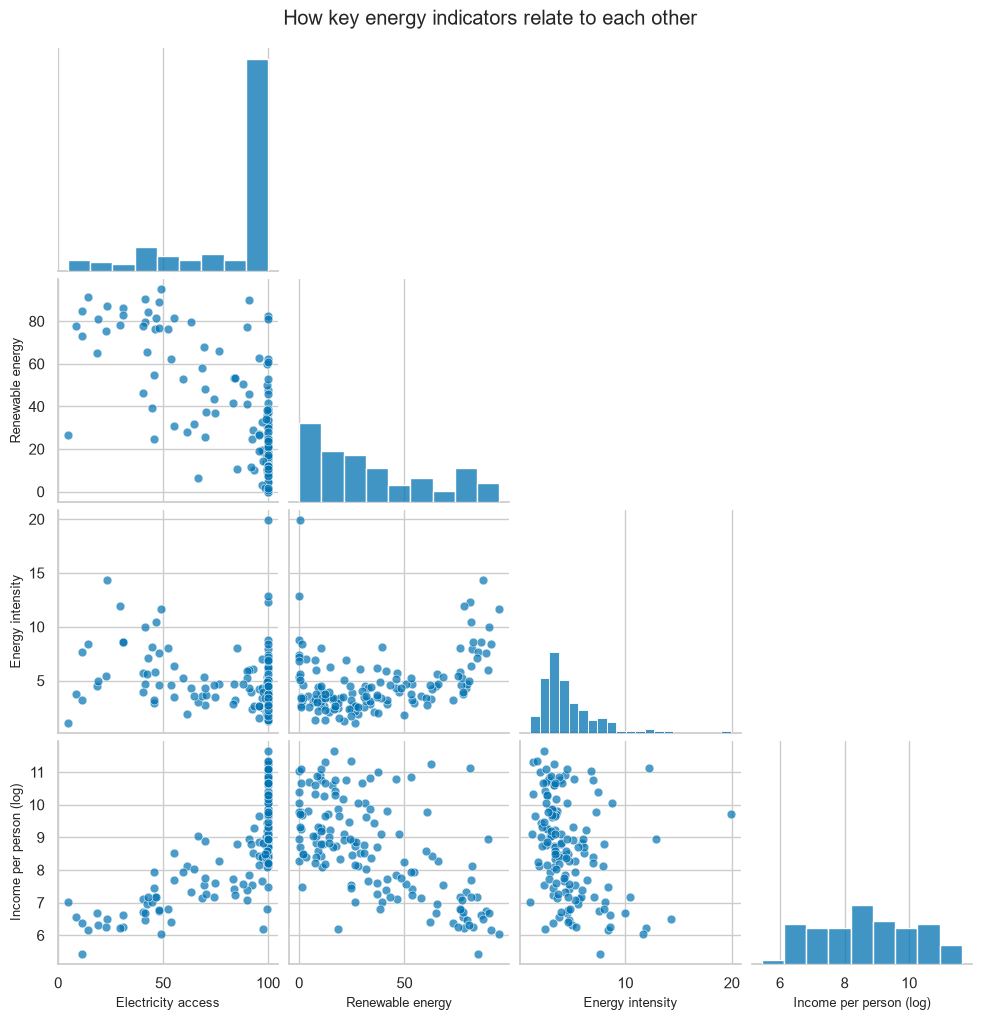

In [5]:
pair_cols = [
    "access_electricity_pct",
    "renewable_energy_share_pct",
    "energy_intensity_mj_per_gdp",
    "log_gdp_per_capita",
]
pair = work[pair_cols].rename(columns=LABELS)
grid = sns.pairplot(
    pair,
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.7, "s": 40, "color": "#0072B2", "edgecolor": "white"},
    diag_kws={"color": "#0072B2"},
)
grid.figure.suptitle("How key energy indicators relate to each other", y=1.02)
for axis in grid.axes.flatten():
    if axis is None:
        continue
    axis.set_xlabel(axis.get_xlabel(), fontsize=9)
    axis.set_ylabel(axis.get_ylabel(), fontsize=9)
save(grid.figure, "scatter_matrix")
plt.show()



## Correlation heatmap

Color shows the strength of each relationship. Blue is a negative relationship, red is a positive one, and white is near zero.


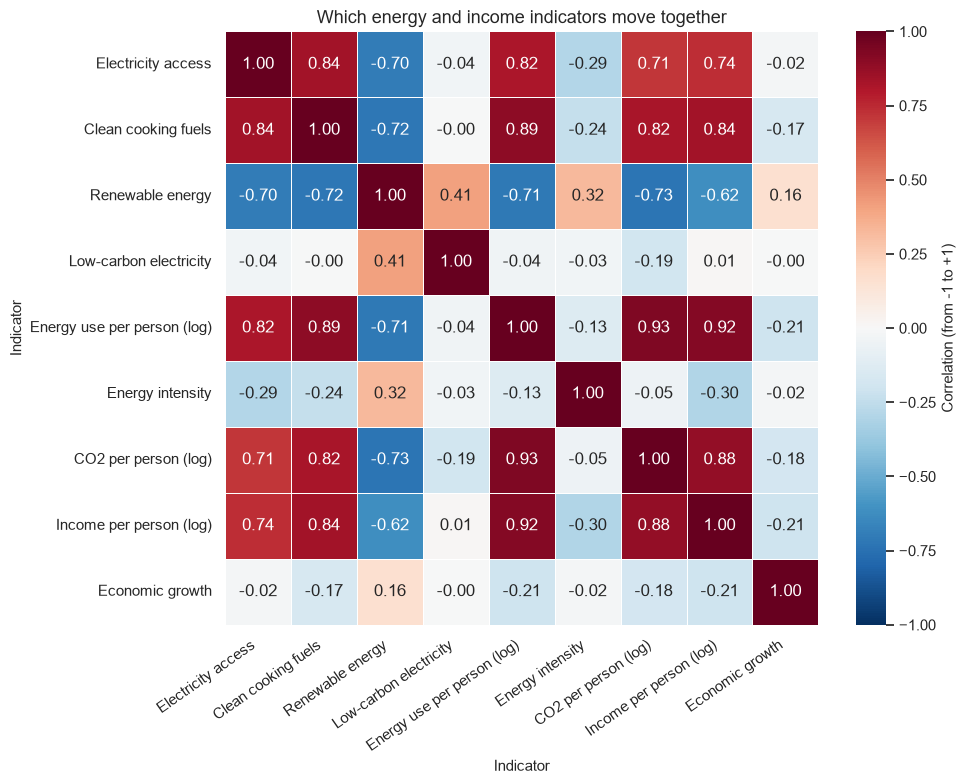

In [6]:
named = work[FEATURES].rename(columns=LABELS)
correlations = named.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.4,
    cbar_kws={"label": "Correlation (from -1 to +1)"},
    ax=ax,
)
ax.set_title("Which energy and income indicators move together")
ax.set_xlabel("Indicator")
ax.set_ylabel("Indicator")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
fig.tight_layout()
save(fig, "correlation_heatmap")
plt.show()



## Principal components analysis

Indicators are standardized first so a percentage and a log-income value can be compared fairly. The scree plot shows how much of the overall variation each new component keeps.


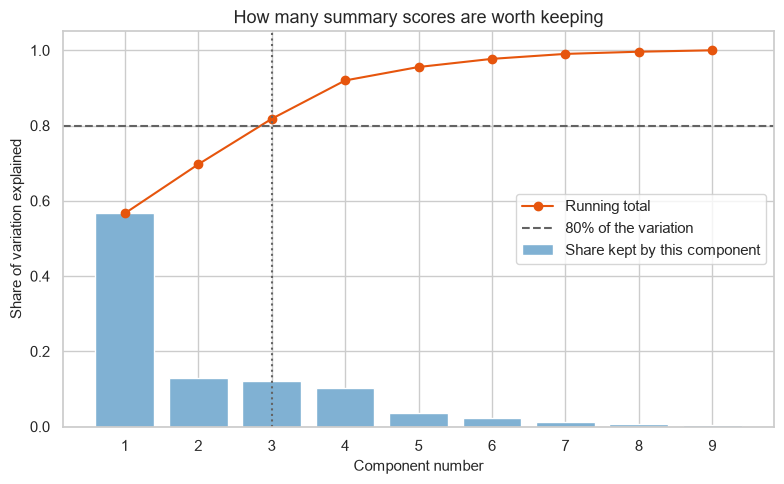

In [7]:
scaler = StandardScaler()
X = scaler.fit_transform(work[FEATURES])

pca_full = PCA()
pca_full.fit(X)
share = pca_full.explained_variance_ratio_
cumulative = np.cumsum(share)
n_keep = int(np.searchsorted(cumulative, 0.80) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
component_number = np.arange(1, len(share) + 1)
ax.bar(component_number, share, color="#80b1d3", label="Share kept by this component")
ax.plot(component_number, cumulative, color="#e6550d", marker="o", label="Running total")
ax.axhline(0.80, color="#636363", linestyle="--", label="80% of the variation")
ax.axvline(n_keep, color="#636363", linestyle=":")
ax.set_xlabel("Component number")
ax.set_ylabel("Share of variation explained")
ax.set_title("How many summary scores are worth keeping")
ax.set_xticks(component_number)
ax.set_ylim(0, 1.05)
ax.legend()
fig.tight_layout()
save(fig, "pca_scree")
plt.show()


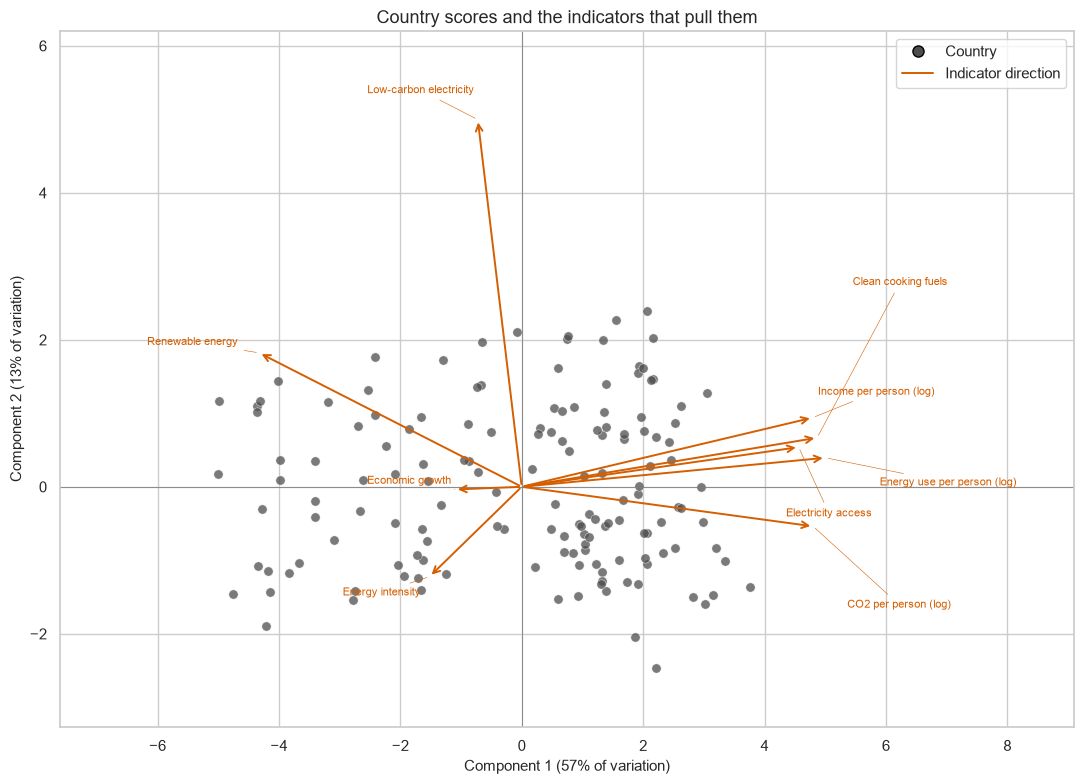

In [8]:
pca = PCA(n_components=2)
scores = pca.fit_transform(X)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
arrow_scale = np.max(np.abs(scores)) / np.max(np.abs(loadings))

fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(scores[:, 0], scores[:, 1], s=45, c="#4d4d4d", alpha=0.75, edgecolors="white", linewidths=0.4)
arrow_ends = loadings[:, :2] * arrow_scale
label_xy = spread_labels(arrow_ends * 1.08, min_dist=1.6)
for index, feature in enumerate(FEATURES):
    ax.annotate(
        "",
        xy=arrow_ends[index],
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color="#D55E00", lw=1.4),
    )
    ax.annotate(
        LABELS[feature],
        xy=arrow_ends[index],
        xytext=label_xy[index],
        color="#D55E00",
        fontsize=8,
        ha="left" if arrow_ends[index, 0] >= 0 else "right",
        va="center",
        arrowprops=dict(arrowstyle="-", color="#D55E00", lw=0.4),
    )
ax.set_xlim(min(scores[:, 0].min(), label_xy[:, 0].min()) - 2.6, max(scores[:, 0].max(), label_xy[:, 0].max()) + 3.2)
ax.set_ylim(min(scores[:, 1].min(), label_xy[:, 1].min()) - 0.8, max(scores[:, 1].max(), label_xy[:, 1].max()) + 0.8)
ax.axhline(0, color="grey", lw=0.6)
ax.axvline(0, color="grey", lw=0.6)
ax.set_xlabel(f"Component 1 ({100 * pca.explained_variance_ratio_[0]:.0f}% of variation)")
ax.set_ylabel(f"Component 2 ({100 * pca.explained_variance_ratio_[1]:.0f}% of variation)")
ax.set_title("Country scores and the indicators that pull them")
ax.legend(
    handles=[
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#4d4d4d", markersize=8, label="Country"),
        Line2D([0], [0], color="#D55E00", lw=1.4, label="Indicator direction"),
    ],
    loc="best",
)
fig.tight_layout()
save(fig, "pca_biplot")
plt.show()

pc1 = pd.Series(pca.components_[0], index=[LABELS[name] for name in FEATURES])


## Factor analysis

The same standardized indicators are described by a smaller set of hidden factors. Varimax rotation makes each indicator load mainly on one factor, which is easier to interpret. The number of factors follows Kaiser's rule: keep factors whose eigenvalue is greater than 1, and keep at least two so the loadings plot has two axes.


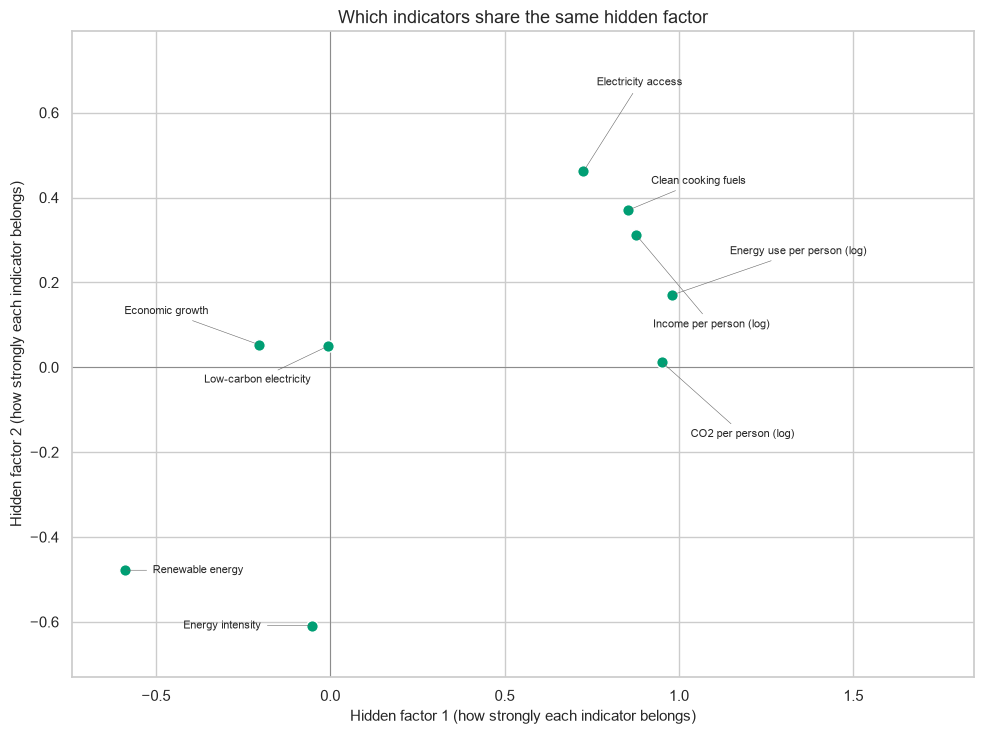

,Hidden factor 1,Hidden factor 2
Electricity access,0.73,0.46
Clean cooking fuels,0.85,0.37
Renewable energy,-0.59,-0.48
Low-carbon electricity,-0.01,0.05
Energy use per person (log),0.98,0.17
Energy intensity,-0.05,-0.61
CO2 per person (log),0.95,0.01
Income per person (log),0.88,0.31
Economic growth,-0.20,0.05


In [9]:
probe = FactorAnalyzer(n_factors=len(FEATURES), rotation=None)
probe.fit(X)
eigenvalues, _ = probe.get_eigenvalues()
n_factors = int((eigenvalues > 1).sum())
n_factors = max(2, n_factors)

factor_model = FactorAnalyzer(n_factors=n_factors, rotation="varimax")
factor_model.fit(X)
factor_loadings = factor_model.loadings_

fig, ax = plt.subplots(figsize=(10, 7.5))
ax.scatter(factor_loadings[:, 0], factor_loadings[:, 1], s=70, c="#009E73", edgecolors="white", zorder=3)
label_xy = spread_labels(factor_loadings[:, :2] + np.array([0.08, 0.0]), min_dist=0.28)
for index in range(len(label_xy)):
    if abs(label_xy[index, 0]) < 0.22:
        label_xy[index, 0] += -0.45 if factor_loadings[index, 0] <= 0 else 0.45
for index, feature in enumerate(FEATURES):
    ax.annotate(
        LABELS[feature],
        xy=(factor_loadings[index, 0], factor_loadings[index, 1]),
        xytext=label_xy[index],
        fontsize=8,
        ha="left",
        va="center",
        arrowprops=dict(arrowstyle="-", color="#666666", lw=0.4),
    )
pad = 0.12
ax.set_xlim(min(factor_loadings[:, 0].min(), label_xy[:, 0].min()) - 0.15, max(factor_loadings[:, 0].max(), label_xy[:, 0].max()) + 0.7)
ax.set_ylim(min(factor_loadings[:, 1].min(), label_xy[:, 1].min()) - pad, max(factor_loadings[:, 1].max(), label_xy[:, 1].max()) + pad)
ax.axhline(0, color="grey", lw=0.6)
ax.axvline(0, color="grey", lw=0.6)
ax.set_xlabel("Hidden factor 1 (how strongly each indicator belongs)")
ax.set_ylabel("Hidden factor 2 (how strongly each indicator belongs)")
ax.set_title("Which indicators share the same hidden factor")
fig.tight_layout()
save(fig, "factor_loadings")
plt.show()

loading_table = pd.DataFrame(
    factor_loadings[:, :2],
    index=[LABELS[name] for name in FEATURES],
    columns=["Hidden factor 1", "Hidden factor 2"],
)
display(loading_table.round(2))


## Discriminant analysis

Countries are split at the median income into two equal-sized groups. Income itself is **not** used as a predictor. The model may use only the energy indicators, so the separation is about energy structure.


Split at the median income of $6,095 per person
income_group
Lower-income countries     74
Higher-income countries    74


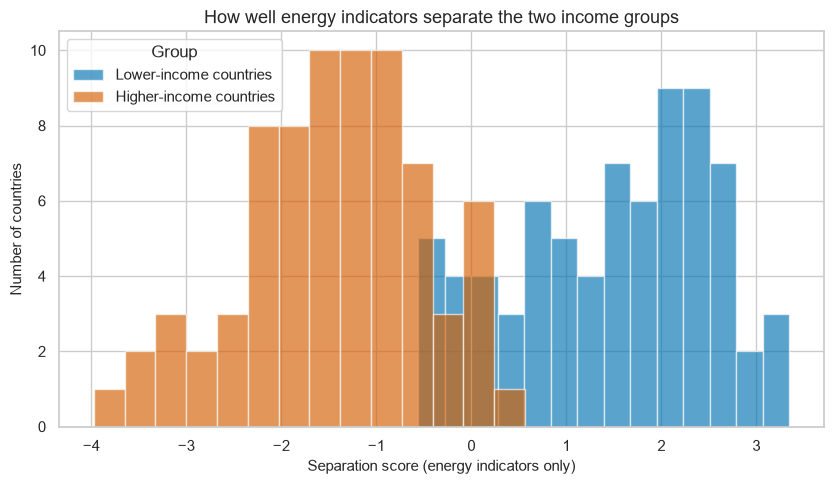

CO2 per person (log)          -4.43
Clean cooking fuels           -2.37
Renewable energy              -1.89
Energy intensity               1.37
Electricity access             0.82
Economic growth                0.30
Energy use per person (log)   -0.30
Low-carbon electricity         0.19
Name: Weight in the separation score, dtype: float64

In [10]:
income_cutoff = work["gdp_per_capita"].median()
work["income_group"] = np.where(
    work["gdp_per_capita"] >= income_cutoff,
    "Higher-income countries",
    "Lower-income countries",
)
print(f"Split at the median income of ${income_cutoff:,.0f} per person")
print(work["income_group"].value_counts().to_string())

X_lda = StandardScaler().fit_transform(work[LDA_FEATURES])
y = work["income_group"]
lda = LinearDiscriminantAnalysis()
separation = lda.fit_transform(X_lda, y)
accuracy = lda.score(X_lda, y)

fig, ax = plt.subplots(figsize=(8.5, 5))
for group, color in GROUP_COLORS.items():
    ax.hist(
        separation[y == group, 0],
        bins=14,
        alpha=0.65,
        color=color,
        edgecolor="white",
        label=group,
    )
ax.set_xlabel("Separation score (energy indicators only)")
ax.set_ylabel("Number of countries")
ax.set_title("How well energy indicators separate the two income groups")
ax.legend(title="Group")
fig.tight_layout()
save(fig, "lda_discriminant")
plt.show()

weights = pd.Series(lda.coef_[0], index=[LABELS[name] for name in LDA_FEATURES])
display(weights.sort_values(key=np.abs, ascending=False).round(2).rename("Weight in the separation score"))
strongest = weights.abs().idxmax()


## Parallel coordinates

Each line is one country. The height of the line is that country's position on each energy indicator, after standardization, so every axis uses the same scale.


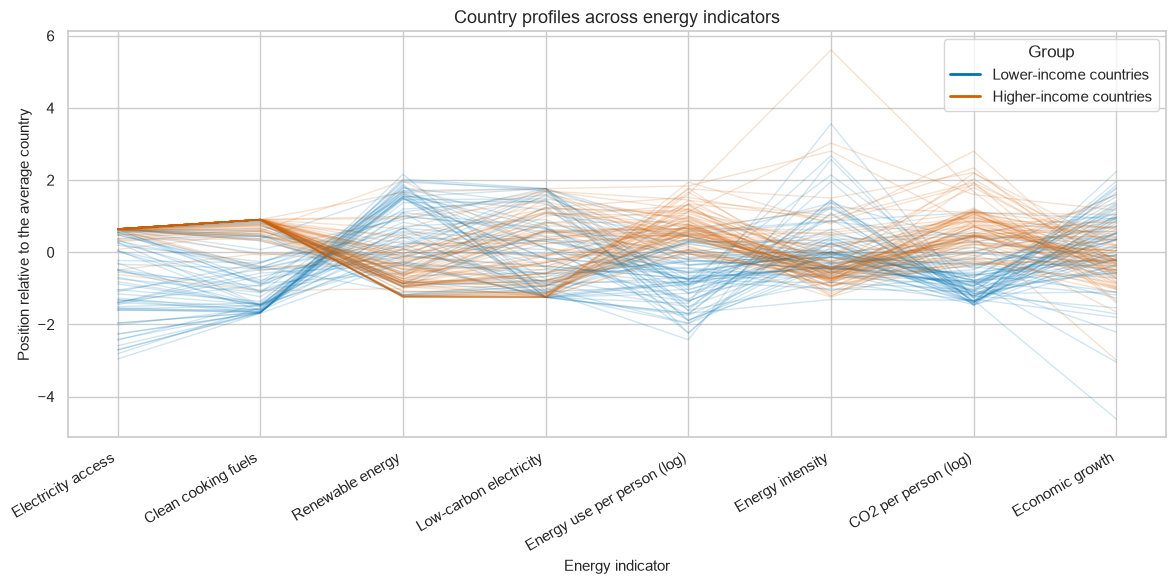

In [11]:
profile = work[LDA_FEATURES].rename(columns=LABELS)
profile = (profile - profile.mean()) / profile.std(ddof=0)
profile["Group"] = work["income_group"].values

fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(LDA_FEATURES))
for group, color in GROUP_COLORS.items():
    rows = profile.loc[profile["Group"] == group, [LABELS[name] for name in LDA_FEATURES]]
    for _, row in rows.iterrows():
        ax.plot(x_pos, row.values, color=color, alpha=0.18, lw=1)
    ax.plot([], [], color=color, lw=2, label=group)
ax.set_xticks(x_pos)
ax.set_xticklabels([LABELS[name] for name in LDA_FEATURES], rotation=30, ha="right")
ax.set_ylabel("Position relative to the average country")
ax.set_xlabel("Energy indicator")
ax.set_title("Country profiles across energy indicators")
ax.legend(title="Group")
fig.tight_layout()
save(fig, "parallel_coordinates")
plt.show()




## Trellis display

The same relationship is repeated for each decade. This uses every country-year from 2000 to 2019, not only the latest year.


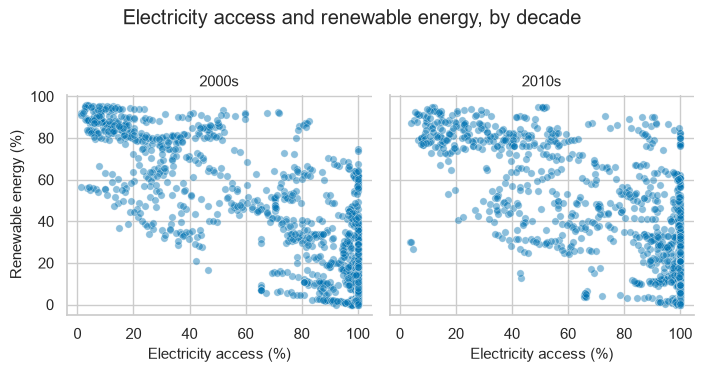

In [12]:
trellis = panel.dropna(subset=["access_electricity_pct", "renewable_energy_share_pct"]).copy()
trellis["Decade"] = (trellis["year"] // 10 * 10).astype(str) + "s"
facet = sns.FacetGrid(trellis, col="Decade", col_wrap=2, height=3.6, sharex=True, sharey=True)
facet.map_dataframe(
    sns.scatterplot,
    x="access_electricity_pct",
    y="renewable_energy_share_pct",
    alpha=0.45,
    s=28,
    color="#0072B2",
    edgecolor="white",
)
facet.set_axis_labels("Electricity access (%)", "Renewable energy (%)")
facet.set_titles("{col_name}")
facet.figure.suptitle("Electricity access and renewable energy, by decade", y=1.03)
facet.figure.tight_layout()
save(facet.figure, "trellis_decade")
plt.show()


## Icon chart: radar glyph

Each spoke is one energy indicator. The shape is the typical (median) country in that income group. Values are stretched from 0 to 1 within each spoke so the icon compares shape rather than units.


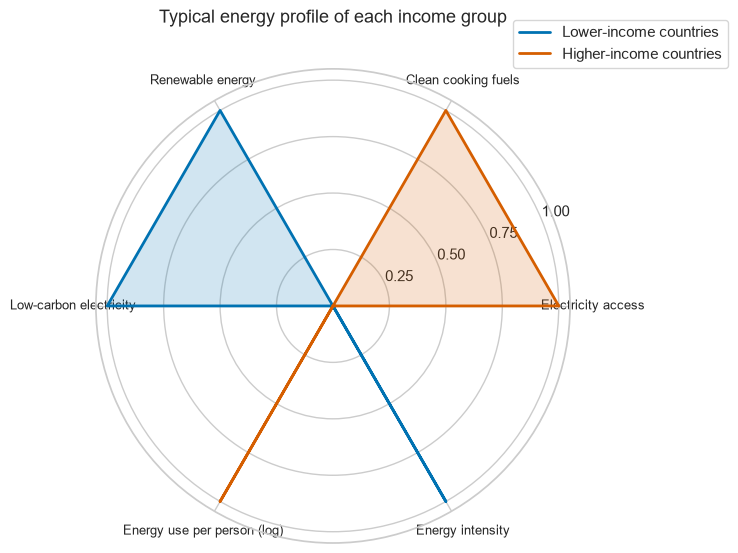

In [13]:
radar_features = LDA_FEATURES[:6]
medians = work.groupby("income_group")[radar_features].median()
span = (medians.max() - medians.min()).replace(0, np.nan)
normalized = ((medians - medians.min()) / span).fillna(0.5)

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False)
angles = np.concatenate([angles, angles[:1]])
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})
for group, color in GROUP_COLORS.items():
    values = normalized.loc[group].tolist()
    values.append(values[0])
    ax.plot(angles, values, color=color, lw=2, label=group)
    ax.fill(angles, values, color=color, alpha=0.18)
ax.set_xticks(angles[:-1])
ax.set_xticklabels([LABELS[name] for name in radar_features], fontsize=9)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_ylim(0, 1.05)
ax.set_title("Typical energy profile of each income group", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.12))
fig.tight_layout()
save(fig, "income_radar_glyph")
plt.show()

